In [2]:
from google.colab import files
uploaded = files.upload()

Saving owid-covid-data.csv to owid-covid-data.csv


In [3]:
import pandas as pd
import numpy as np

# Load your uploaded file
df = pd.read_csv('owid-covid-data.csv')
print("✅ Data Loaded! Shape:", df.shape)
df.head()

✅ Data Loaded! Shape: (350085, 67)


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


In [4]:
import numpy as np

# Select key columns
cols = [
    'iso_code', 'continent', 'location', 'date',
    'total_cases', 'new_cases', 'total_deaths', 'new_deaths',
    'total_vaccinations', 'people_fully_vaccinated',
    'total_cases_per_million', 'total_deaths_per_million',
    'population', 'gdp_per_capita', 'human_development_index',
    'stringency_index', 'reproduction_rate'
]
df = df[cols]

# Keep countries only
df = df[df['continent'].notna()]

# Convert date
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M').astype(str)

# Fill missing values
num_cols = ['total_cases','new_cases','total_deaths',
            'new_deaths','total_vaccinations','people_fully_vaccinated']
df[num_cols] = df[num_cols].fillna(0)

# Add calculated columns
df['fatality_rate'] = (df['total_deaths'] / df['total_cases'].replace(0, np.nan) * 100).round(2)
df['vaccination_rate'] = (df['people_fully_vaccinated'] / df['population'] * 100).round(2)

print("✅ Cleaning Done! Shape:", df.shape)
df.head()

✅ Cleaning Done! Shape: (333420, 22)


,iso_code,continent,location,date,total_cases,new_cases,total_deaths,new_deaths,total_vaccinations,people_fully_vaccinated,...,population,gdp_per_capita,human_development_index,stringency_index,reproduction_rate,year,month,year_month,fatality_rate,vaccination_rate
0,AFG,Asia,Afghanistan,2020-01-03,0.0,0.0,0.0,0.0,0.0,0.0,...,41128772.0,1803.987,0.511,0.0,NaN,2020,1,2020-01,NaN,0.0
1,AFG,Asia,Afghanistan,2020-01-04,0.0,0.0,0.0,0.0,0.0,0.0,...,41128772.0,1803.987,0.511,0.0,NaN,2020,1,2020-01,NaN,0.0
2,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,...,41128772.0,1803.987,0.511,0.0,NaN,2020,1,2020-01,NaN,0.0
3,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,0.0,0.0,0.0,0.0,...,41128772.0,1803.987,0.511,0.0,NaN,2020,1,2020-01,NaN,0.0
4,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,0.0,0.0,0.0,0.0,...,41128772.0,1803.987,0.511,0.0,NaN,2020,1,2020-01,NaN,0.0


/tmp/ipykernel_2562/1540215169.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=latest, x='total_cases', y='location', palette='Reds_r')


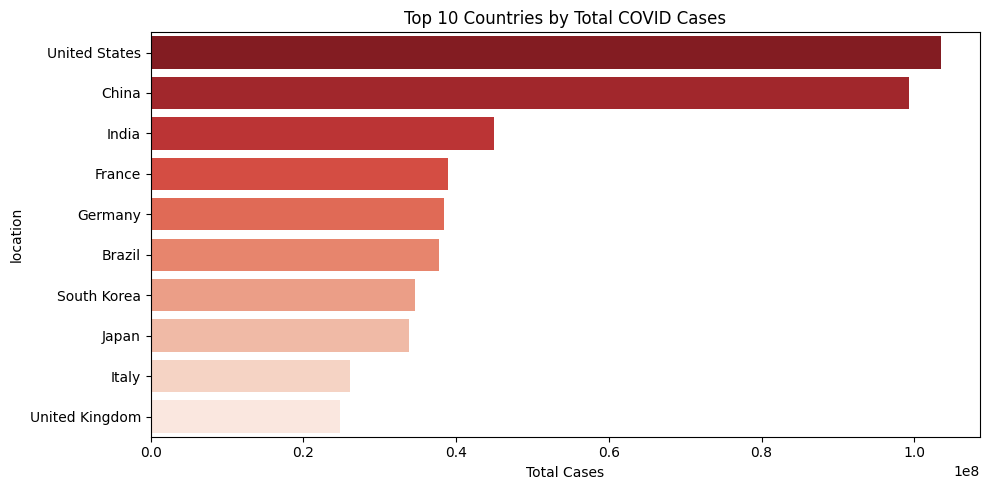

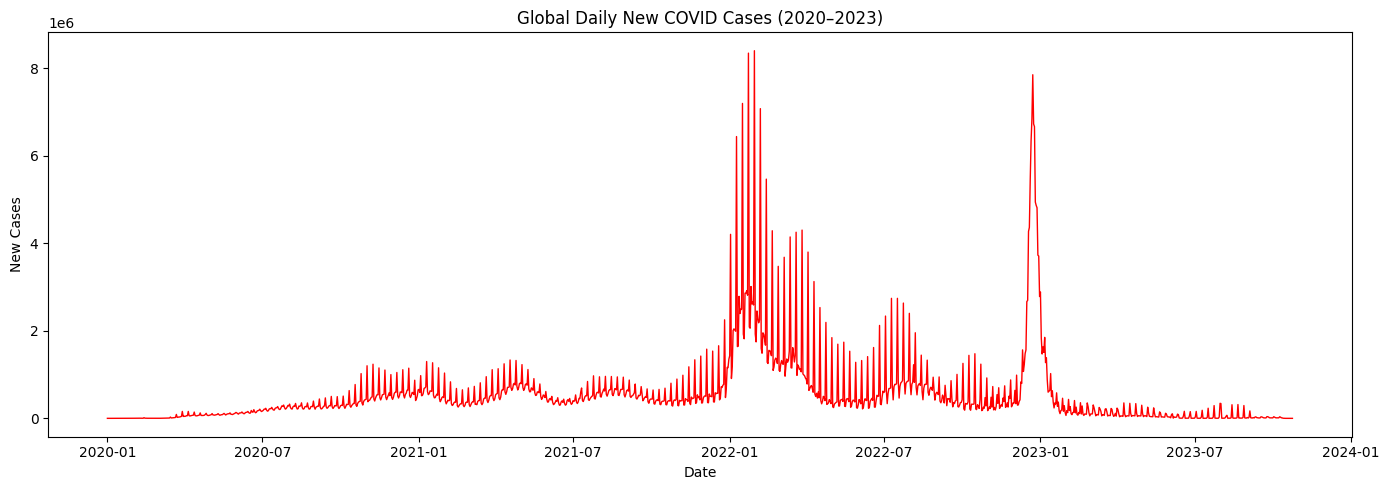

/tmp/ipykernel_2562/1540215169.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cont, x='continent', y='fatality_rate', palette='Blues_d')


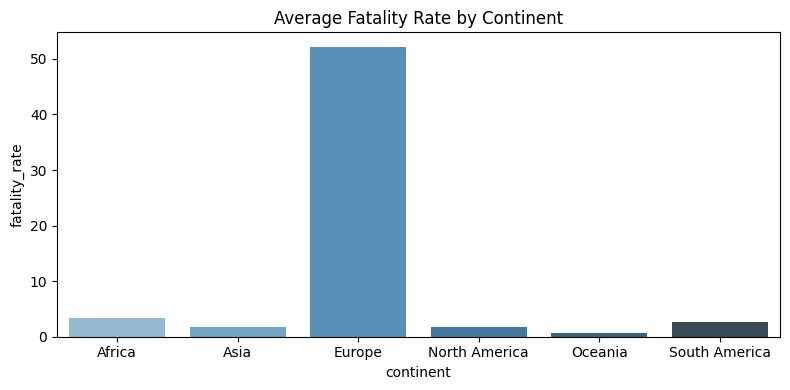

/tmp/ipykernel_2562/1540215169.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vax, x='continent', y='vaccination_rate', palette='Greens_d')


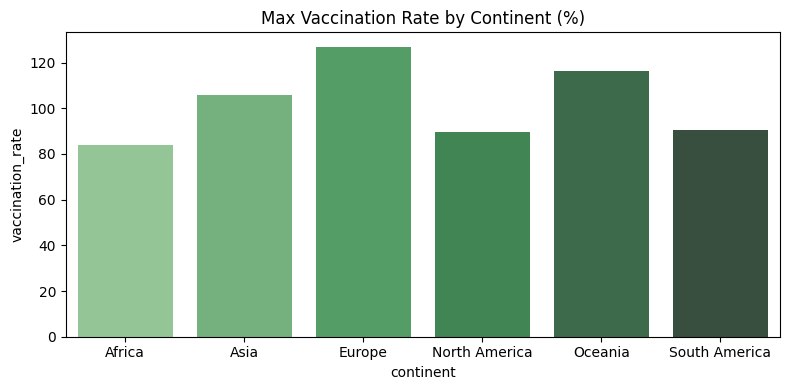

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Top 10 Countries by Total Cases
latest = df.groupby('location')['total_cases'].max().nlargest(10).reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=latest, x='total_cases', y='location', palette='Reds_r')
plt.title('Top 10 Countries by Total COVID Cases')
plt.xlabel('Total Cases')
plt.tight_layout()
plt.show()

# Chart 2: Global Daily New Cases Trend
global_trend = df.groupby('date')['new_cases'].sum().reset_index()
plt.figure(figsize=(14,5))
plt.plot(global_trend['date'], global_trend['new_cases'], color='red', linewidth=1)
plt.title('Global Daily New COVID Cases (2020–2023)')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.tight_layout()
plt.show()

# Chart 3: Fatality Rate by Continent
cont = df.groupby('continent')['fatality_rate'].mean().reset_index()
plt.figure(figsize=(8,4))
sns.barplot(data=cont, x='continent', y='fatality_rate', palette='Blues_d')
plt.title('Average Fatality Rate by Continent')
plt.tight_layout()
plt.show()

# Chart 4: Vaccination Rate by Continent
vax = df.groupby('continent')['vaccination_rate'].max().reset_index()
plt.figure(figsize=(8,4))
sns.barplot(data=vax, x='continent', y='vaccination_rate', palette='Greens_d')
plt.title('Max Vaccination Rate by Continent (%)')
plt.tight_layout()
plt.show()

In [6]:
df.to_csv('covid_cleaned.csv', index=False)

from google.colab import files
files.download('covid_cleaned.csv')
print("✅ covid_cleaned.csv downloaded! Ready for Tableau!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ covid_cleaned.csv downloaded! Ready for Tableau!
